# 04 - Multi-Objective Bayesian Optimization (Stretch)

Optimize dissolution, hardness, and friability jointly using qNEHVI.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.acquisition.multi_objective.monte_carlo import qNoisyExpectedHypervolumeImprovement
from botorch.sampling.normal import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

plt.style.use('seaborn-v0_8-whitegrid')
torch.set_default_dtype(torch.double)

In [2]:
import numpy as np
import pandas as pd

API_PCT = 30.0
TOTAL_EXCIPIENT_PCT = 100.0 - API_PCT

BOUNDS = {
    "hpmc": (0.0, 20.0),
    "mcc": (20.0, 60.0),
    "ccs": (1.0, 8.0),
    "mgst": (0.25, 2.0),
    "pvp": (0.0, 10.0),
}


def _physics_q45(hpmc, mcc, ccs, mgst, pvp):
    """
    Physics-informed synthetic dissolution model (% released at 45 min).

    Scientific assumptions encoded:
    - HPMC retards dissolution with nonlinear gel-layer penalty.
    - CCS improves dissolution with a saturable response.
    - MgSt reduces dissolution due to hydrophobic film formation.
    - MCC and PVP provide mild positive wetting/compactibility effects.
    - HPMC × CCS interaction reduces CCS effectiveness at high HPMC.
    """
    ccs_gain = 24.0 * (1.0 - np.exp(-ccs / 2.2))
    q45 = (
        48.0
        + 0.45 * mcc
        + 0.90 * pvp
        + ccs_gain
        - 1.05 * hpmc
        - 0.035 * (hpmc ** 2)
        - 7.2 * mgst
        - 0.16 * hpmc * ccs
    )
    return np.clip(q45, 0.0, 100.0)


def simulate_dissolution(df, noise_std=2.0, seed=0):
    """Simulate Q45 for one or many formulations."""
    rng = np.random.default_rng(seed)
    expected = _physics_q45(
        df["hpmc"].to_numpy(),
        df["mcc"].to_numpy(),
        df["ccs"].to_numpy(),
        df["mgst"].to_numpy(),
        df["pvp"].to_numpy(),
    )
    observed = expected + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(observed, 0.0, 100.0)


def is_feasible(df):
    """Check formulation bounds and mass-balance constraints."""
    checks = []
    for name, (lo, hi) in BOUNDS.items():
        checks.append(df[name].between(lo, hi))
    sum_ok = np.isclose(df[["hpmc", "mcc", "ccs", "mgst", "pvp"]].sum(axis=1), TOTAL_EXCIPIENT_PCT, atol=1e-6)
    return np.logical_and.reduce(checks + [sum_ok])


def sample_feasible(n, seed=0):
    """Rejection sample feasible formulations under x5 = 70 - (x1+x2+x3+x4)."""
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n:
        hpmc = rng.uniform(*BOUNDS["hpmc"])
        mcc = rng.uniform(*BOUNDS["mcc"])
        ccs = rng.uniform(*BOUNDS["ccs"])
        mgst = rng.uniform(*BOUNDS["mgst"])
        pvp = TOTAL_EXCIPIENT_PCT - (hpmc + mcc + ccs + mgst)
        if BOUNDS["pvp"][0] <= pvp <= BOUNDS["pvp"][1]:
            rows.append((hpmc, mcc, ccs, mgst, pvp))
    return pd.DataFrame(rows, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])

In [3]:
TORCH_BOUNDS = torch.tensor([
    [BOUNDS["hpmc"][0], BOUNDS["mcc"][0], BOUNDS["ccs"][0], BOUNDS["mgst"][0]],
    [BOUNDS["hpmc"][1], BOUNDS["mcc"][1], BOUNDS["ccs"][1], BOUNDS["mgst"][1]],
], dtype=torch.double)


def augment_with_pvp(X4):
    pvp = TOTAL_EXCIPIENT_PCT - X4.sum(dim=-1, keepdim=True)
    return torch.cat([X4, pvp], dim=-1)


def feasible_mask(X4):
    pvp = TOTAL_EXCIPIENT_PCT - X4.sum(dim=-1)
    return (pvp >= BOUNDS["pvp"][0]) & (pvp <= BOUNDS["pvp"][1])


def sample_sobol_feasible(n, seed=0):
    sobol = torch.quasirandom.SobolEngine(dimension=4, scramble=True, seed=seed)
    out = []
    while len(out) < n:
        X = sobol.draw(4 * n)
        X = TORCH_BOUNDS[0] + (TORCH_BOUNDS[1] - TORCH_BOUNDS[0]) * X
        X = X[feasible_mask(X)]
        out.extend([x for x in X])
    return torch.stack(out[:n])


def simulate_hardness(df, noise_std=3.0, seed=0):
    rng = np.random.default_rng(seed)
    hardness = (
        85.0
        + 0.65 * df["pvp"].to_numpy()
        + 0.25 * df["mcc"].to_numpy()
        + 0.35 * df["hpmc"].to_numpy()
        - 8.5 * df["ccs"].to_numpy()
        - 4.5 * df["mgst"].to_numpy()
        - 0.015 * (df["hpmc"].to_numpy() ** 2)
    )
    hardness = hardness + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(hardness, 30.0, 220.0)


def simulate_friability(df, noise_std=0.08, seed=0):
    rng = np.random.default_rng(seed)
    friability = (
        1.35
        - 0.018 * df["pvp"].to_numpy()
        - 0.009 * df["mcc"].to_numpy()
        + 0.020 * df["ccs"].to_numpy()
        + 0.060 * df["mgst"].to_numpy()
        - 0.004 * df["hpmc"].to_numpy()
    )
    friability = friability + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(friability, 0.2, 2.5)


def simulate_multi_obj(X4, seed=0):
    X = augment_with_pvp(X4).detach().cpu().numpy()
    df = pd.DataFrame(X, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])
    q45 = simulate_dissolution(df, seed=seed)
    hard = simulate_hardness(df, seed=seed + 17)
    friab = simulate_friability(df, seed=seed + 31)
    # Convert to maximization problem by negating friability.
    Y = np.column_stack([q45, hard, -friab])
    return torch.tensor(Y, dtype=torch.double)

In [4]:
def fit_model(X, Y):
    model = SingleTaskGP(
        X,
        Y,
        input_transform=Normalize(d=4),
        outcome_transform=Standardize(m=3),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


def pareto_mask(Y):
    # Maximization Pareto dominance mask.
    n = Y.shape[0]
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        dominates_i = np.all(Y >= Y[i], axis=1) & np.any(Y > Y[i], axis=1)
        if np.any(dominates_i):
            keep[i] = False
    return keep

## Run qNEHVI loop

In [5]:
n_init = 12
n_iter = 24
seed = 123

X = sample_sobol_feasible(n_init, seed=seed)
Y = simulate_multi_obj(X, seed=seed)

ineq = [
    (torch.tensor([0, 1, 2, 3]), torch.tensor([1.0, 1.0, 1.0, 1.0], dtype=torch.double), 60.0),
    (torch.tensor([0, 1, 2, 3]), torch.tensor([-1.0, -1.0, -1.0, -1.0], dtype=torch.double), -70.0),
]

for t in range(n_iter):
    model = fit_model(X, Y)
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([128]))

    # Reference point in transformed objective space (all maximized).
    ref_point = torch.tensor([65.0, 70.0, -1.6], dtype=torch.double)

    acqf = qNoisyExpectedHypervolumeImprovement(
        model=model,
        ref_point=ref_point.tolist(),
        X_baseline=X,
        sampler=sampler,
        prune_baseline=True,
    )

    x_next, _ = optimize_acqf(
        acq_function=acqf,
        bounds=TORCH_BOUNDS,
        q=1,
        num_restarts=15,
        raw_samples=192,
        inequality_constraints=ineq,
    )
    y_next = simulate_multi_obj(x_next, seed=seed + 300 + t)

    X = torch.cat([X, x_next], dim=0)
    Y = torch.cat([Y, y_next], dim=0)

print(f"Completed {n_init + n_iter} total evaluations")

Completed 36 total evaluations


In [6]:
Y_np = Y.detach().cpu().numpy()
mask = pareto_mask(Y_np)
pareto = Y_np[mask]

df = pd.DataFrame(augment_with_pvp(X).detach().cpu().numpy(), columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])
df["q45"] = Y_np[:, 0]
df["hardness"] = Y_np[:, 1]
df["friability"] = -Y_np[:, 2]
df["pareto"] = mask

df[df["pareto"]].sort_values("q45", ascending=False).head(10).round(3)

,hpmc,mcc,ccs,mgst,pvp,q45,hardness,friability,pareto
27,0.000,57.444,3.123,0.250,9.183,100.000,76.903,0.753,True
19,1.427,56.144,2.179,0.250,10.000,99.353,86.650,0.773,True
21,0.000,59.060,2.627,0.250,8.063,98.178,81.738,0.701,True
34,0.000,56.897,2.853,0.250,10.000,98.090,80.257,0.644,True
32,0.000,57.918,1.832,0.250,10.000,97.851,90.172,0.760,True
25,0.000,58.509,2.071,0.250,9.171,95.310,90.773,0.733,True
20,0.000,58.750,1.000,0.250,10.000,91.626,98.310,0.674,True
30,0.000,58.446,1.304,0.250,10.000,89.398,99.272,0.633,True
18,3.396,55.350,1.000,0.254,10.000,85.878,101.240,0.717,True


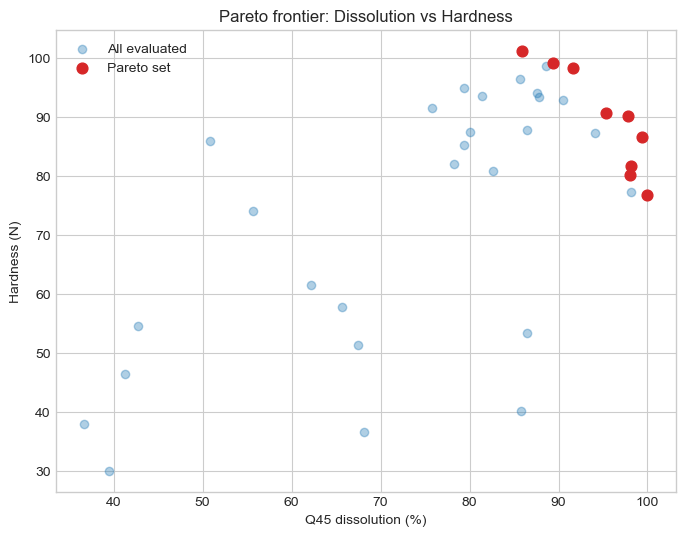

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["q45"], df["hardness"], alpha=0.35, label="All evaluated")
ax.scatter(df.loc[df["pareto"], "q45"], df.loc[df["pareto"], "hardness"],
           color="tab:red", s=60, label="Pareto set")
ax.set_xlabel("Q45 dissolution (%)")
ax.set_ylabel("Hardness (N)")
ax.set_title("Pareto frontier: Dissolution vs Hardness")
ax.legend()
plt.show()

## Multi-objective interpretation

- Pareto points expose trade-offs: higher dissolution may reduce hardness or worsen friability.
- qNEHVI efficiently samples high-value compromises compared with scalarizing objectives too early.
- Formulation scientists can choose operating points based on CQA priorities and downstream process risk.